# Task 1

**installation environment**

In [5]:
!pip install transformers datasets accelerate scikit-learn

**Download the dataset**

In [6]:
# Download the main dataset file
!wget -O dontpatronizeme_pcl.tsv https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv

# Download the partition files of the training set and the development set
!wget https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/train_semeval_parids-labels.csv
!wget https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/dev_semeval_parids-labels.csv

# Download the test set
!wget https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/TEST/task4_test.tsv

# Download the classification details dataset
!wget -O dontpatronizeme_categories.tsv https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_categories.tsv

--2026-02-28 16:35:30--  https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3122842 (3.0M) [text/plain]
Saving to: ‘dontpatronizeme_pcl.tsv’

dontpatronizeme_pcl 100%[===================>]   2.98M  --.-KB/s    in 0.01s   

2026-02-28 16:35:30 (298 MB/s) - ‘dontpatronizeme_pcl.tsv’ saved [3122842/3122842]

--2026-02-28 16:35:30--  https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/train_semeval_parids-labels.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)

**Construct the official split**

In [7]:
import pandas as pd

data = pd.read_csv("dontpatronizeme_pcl.tsv", sep="\t", skiprows=4)
data.columns = ["par_id","art_id","keyword","country","text","orig_label"]

# turn to binary
data["label"] = data["orig_label"].apply(lambda x: 0 if x in [0,1] else 1)

train_ids = pd.read_csv("train_semeval_parids-labels.csv")
dev_ids = pd.read_csv("dev_semeval_parids-labels.csv")

data['par_id_str'] = data['par_id'].astype(str).str.strip()

train_df = data[data.par_id_str.isin(train_ids.par_id.astype(str).str.strip())].copy()
dev_df = data[data.par_id_str.isin(dev_ids.par_id.astype(str).str.strip())].copy()

print(train_df.label.value_counts())
print(dev_df.label.value_counts())

label
0    7580
1     794
Name: count, dtype: int64
label
0    1895
1     199
Name: count, dtype: int64


In [8]:
# After filtering, handle the null values immediately
train_df = train_df.dropna(subset=['text']).copy()
dev_df = dev_df.dropna(subset=['text']).copy()

# Forcing text to be of string type - the core to resolving TypeError
train_df['text'] = train_df['text'].astype(str)
dev_df['text'] = dev_df['text'].astype(str)

print(f"Final Train size: {len(train_df)}")
print(f"Final Dev size: {len(dev_df)}")

Final Train size: 8374
Final Dev size: 2093


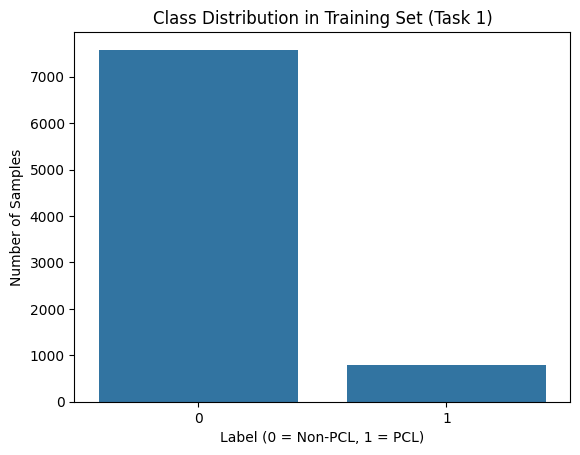

label
0    7580
1     794
Name: count, dtype: int64


In [9]:
# =========================
# EDA 1: Class Distribution
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x=train_df["label"])
plt.title("Class Distribution in Training Set (Task 1)")
plt.xlabel("Label (0 = Non-PCL, 1 = PCL)")
plt.ylabel("Number of Samples")
plt.show()

print(train_df["label"].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (543 > 512). Running this sequence through the model will result in indexing errors


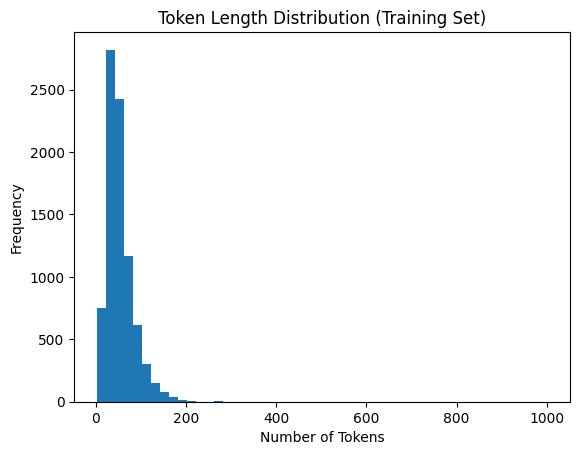

Mean length: 53.753522808693575
Max length: 1002


In [10]:
# =========================
# EDA 2: Token Length Distribution
# =========================

from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

lengths = train_df["text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

plt.figure()
plt.hist(lengths, bins=50)
plt.title("Token Length Distribution (Training Set)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

print("Mean length:", lengths.mean())
print("Max length:", lengths.max())

In [11]:
import re

def clean_text(text):
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    # Remove the redundant line breaks and Spaces
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Application cleaning
train_df['text'] = train_df['text'].apply(clean_text)
dev_df['text'] = dev_df['text'].apply(clean_text)

**tokenization**

In [12]:
from transformers import RobertaTokenizer
from datasets import Dataset

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_dataset = Dataset.from_pandas(train_df[["text","label"]])
dev_dataset = Dataset.from_pandas(dev_df[["text","label"]])

def tokenize(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
dev_dataset = dev_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
dev_dataset = dev_dataset.rename_column("label", "labels")
train_dataset.set_format("torch", columns=["input_ids","attention_mask","labels"])
dev_dataset.set_format("torch", columns=["input_ids","attention_mask","labels"])

Map:   0%|          | 0/8374 [00:00<?, ? examples/s]

Map:   0%|          | 0/2093 [00:00<?, ? examples/s]

**Calculate class weights**

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df.label),
    y=train_df.label
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([0.5524, 5.2733])


**Custom Trainer**

In [14]:
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
from torch import nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, 2), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

**Training Parameters**

In [15]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
)

**F1 calculation**

In [16]:
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"f1": f1_score(labels, preds)}

**Training**

In [17]:
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

trainer.train()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,0.593458,0.289770,0.558891
2,0.466745,0.389541,0.521173
3,0.379827,0.482105,0.593458
4,0.279134,0.532331,0.597087


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2096, training_loss=0.42094537775025115, metrics={'train_runtime': 365.1972, 'train_samples_per_second': 91.72, 'train_steps_per_second': 5.739, 'total_flos': 4406583955169280.0, 'train_loss': 0.42094537775025115, 'epoch': 4.0})

**Dev result**

In [18]:
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.5323314666748047, 'eval_f1': 0.5970873786407767, 'eval_runtime': 6.7828, 'eval_samples_per_second': 308.573, 'eval_steps_per_second': 19.313, 'epoch': 4.0}


**Threshold tuning**

In [19]:
predictions = trainer.predict(dev_dataset)
logits = predictions.predictions
labels = predictions.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

best_f1 = 0
best_t = 0

for t in np.arange(0.1,0.9,0.05):
    preds = (probs[:,1] > t).astype(int)
    f1 = f1_score(labels, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.20000000000000004
Best F1: 0.6125290023201856


In [20]:
# ==========================================
# Task 1: Generate Test Predictions (test.txt)
# ==========================================
import torch
import numpy as np
import pandas as pd
from datasets import Dataset

print("Starting prediction on Task 4 Test Set...")

# 1. Load the test set
test_path = "task4_test.tsv"
test_df_raw = pd.read_csv(test_path, sep="\t", header=None)
test_df_raw.columns = ["par_id", "art_id", "keyword", "country", "text"]

# 2. Handle null values
test_df_raw['text'] = test_df_raw['text'].fillna("").astype(str)

# 3. turn to HuggingFace Dataset
test_dataset = Dataset.from_pandas(test_df_raw[["text"]])

# 4. Tokenize
def tokenize_for_test(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

test_dataset_mapped = test_dataset.map(tokenize_for_test, batched=True)
test_dataset_mapped.set_format("torch", columns=["input_ids", "attention_mask"])

# 5. Obtain the predicted probability
test_predictions = trainer.predict(test_dataset_mapped)
test_logits = test_predictions.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

# 6. Apply the best_t obtained during training
final_test_preds = (test_probs[:, 1] > best_t).astype(int)

# 7. Save it as test.txt
with open("test.txt", "w", encoding="utf-8") as f:
    for val in final_test_preds:
        f.write(f"{val}\n")

print("-" * 30)
print(f"Success! 'test.txt' has been generated.")
print(f"Total lines: {len(final_test_preds)}")

Starting prediction on Task 4 Test Set...


Map:   0%|          | 0/3832 [00:00<?, ? examples/s]

------------------------------
Success! 'test.txt' has been generated.
Total lines: 3832


In [21]:
# ==========================================
# Task 1: Generate Dev Predictions (dev.txt)
# ==========================================
print("Generating dev.txt for submission...")

# Obtain the predictions of the validation set
dev_predictions = trainer.predict(dev_dataset)
dev_logits = dev_predictions.predictions
dev_probs = torch.softmax(torch.tensor(dev_logits), dim=1).numpy()

# Use the best_t found previously
final_dev_preds = (dev_probs[:, 1] > best_t).astype(int)

# Save file
with open("dev.txt", "w", encoding="utf-8") as f:
    for val in final_dev_preds:
        f.write(f"{val}\n")

print(f"Success! 'dev.txt' generated with {len(final_dev_preds)} lines.")

Generating dev.txt for submission...


Success! 'dev.txt' generated with 2093 lines.


# Task 2

**Create Task 2 Official Multi-Label Split**

In [22]:
# =========================
# TASK 2 – Construct Official Multi-Label Split (FIXED)
# =========================

import pandas as pd
from ast import literal_eval

# 1. Read the official split
train_ids = pd.read_csv("train_semeval_parids-labels.csv")
dev_ids = pd.read_csv("dev_semeval_parids-labels.csv")

# 2. Convert the label string to a list (Task 2 is multi-label)
train_ids["label"] = train_ids["label"].apply(literal_eval)
dev_ids["label"] = dev_ids["label"].apply(literal_eval)

# 3. Prepare the basic data
data["par_id_str"] = data["par_id"].astype(str).str.strip()

# 4. Construct train_df_task2
# When merging, only take the text and par_id_str of data to avoid label column conflicts
train_df_task2 = train_ids[["par_id", "label"]].copy()
train_df_task2["par_id_str"] = train_df_task2["par_id"].astype(str).str.strip()

train_df_task2 = train_df_task2.merge(
    data[["par_id_str", "text"]],
    on="par_id_str",
    how="left"
)

# 5. Construct dev_df_task2
dev_df_task2 = dev_ids[["par_id", "label"]].copy()
dev_df_task2["par_id_str"] = dev_df_task2["par_id"].astype(str).str.strip()

dev_df_task2 = dev_df_task2.merge(
    data[["par_id_str", "text"]],
    on="par_id_str",
    how="left"
)

# 6. Clear null values and force type conversion
train_df_task2 = train_df_task2.dropna(subset=["text"]).copy()
dev_df_task2 = dev_df_task2.dropna(subset=["text"]).copy()
train_df_task2["text"] = train_df_task2["text"].astype(str)
dev_df_task2["text"] = dev_df_task2["text"].astype(str)

print("Train size:", len(train_df_task2))
print("Dev size:", len(dev_df_task2))
print("Columns:", train_df_task2.columns.tolist())

Train size: 8374
Dev size: 2093
Columns: ['par_id', 'label', 'par_id_str', 'text']


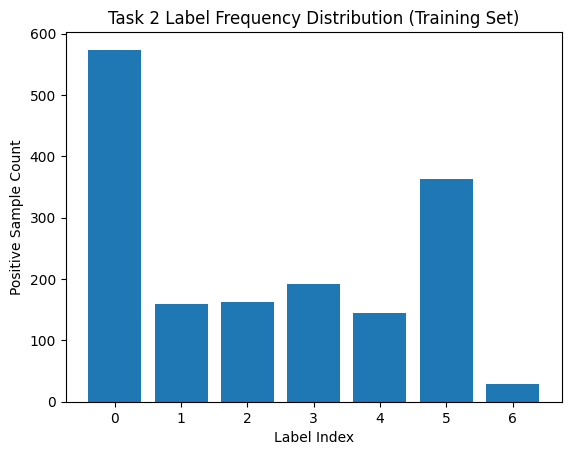

Label counts: [574 160 162 192 145 363  29]


In [23]:
# =========================
# EDA: Task 2 Label Distribution
# =========================

import numpy as np
import matplotlib.pyplot as plt

labels_matrix = np.array(train_df_task2["label"].tolist())

label_freq = labels_matrix.sum(axis=0)

plt.figure()
plt.bar(range(7), label_freq)
plt.title("Task 2 Label Frequency Distribution (Training Set)")
plt.xlabel("Label Index")
plt.ylabel("Positive Sample Count")
plt.show()

print("Label counts:", label_freq)

In [24]:
# Executed before constructing the Dataset
train_df_task2["label"] = train_df_task2["label"].apply(lambda x: [float(i) for i in x])
dev_df_task2["label"] = dev_df_task2["label"].apply(lambda x: [float(i) for i in x])

**Convert to the HuggingFace Dataset**

In [25]:
# =========================
# Convert to HuggingFace Dataset
# =========================

from datasets import Dataset

train_dataset_task2 = Dataset.from_pandas(
    train_df_task2[["text","label"]]
)

dev_dataset_task2 = Dataset.from_pandas(
    dev_df_task2[["text","label"]]
)

# The tokenizer uses the previous roberta-base tokenizer

def tokenize_task2(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_dataset_task2 = train_dataset_task2.map(tokenize_task2, batched=True)
dev_dataset_task2 = dev_dataset_task2.map(tokenize_task2, batched=True)

train_dataset_task2 = train_dataset_task2.rename_column("label", "labels")
dev_dataset_task2 = dev_dataset_task2.rename_column("label", "labels")
train_dataset_task2.set_format(
    "torch",
    columns=["input_ids","attention_mask","labels"]
)

dev_dataset_task2.set_format(
    "torch",
    columns=["input_ids","attention_mask","labels"]
)

Map:   0%|          | 0/8374 [00:00<?, ? examples/s]

Map:   0%|          | 0/2093 [00:00<?, ? examples/s]

In [26]:
# =========================
# Calculate pos_weight for multi-label
# =========================

import torch
import numpy as np

labels_matrix = np.array(train_df_task2["label"].tolist())

# The number of positive samples for each label
pos_counts = labels_matrix.sum(axis=0)

# Negative sample size
neg_counts = len(labels_matrix) - pos_counts

pos_weight = torch.tensor(
    neg_counts / (pos_counts + 1e-6),
    dtype=torch.float32
)

print("Pos weight:", pos_weight)

Pos weight: tensor([ 13.5889,  51.3375,  50.6914,  42.6146,  56.7517,  22.0689, 287.7586])


In [27]:
# =========================
# Custom Multi-Label Trainer
# =========================

from transformers import RobertaForSequenceClassification
from torch import nn
from transformers import Trainer

class MultiLabelTrainer(Trainer):
    def __init__(self, pos_weight, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Make sure the pos_weight is on the correct device and with the right precision
        device = logits.device
        dtype = logits.dtype
        pw = self.pos_weight.to(device=device, dtype=dtype)

        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pw)

        # Explicitly convert labels to the same float type as logits for calculation
        loss = loss_fct(logits, labels.to(dtype))

        return (loss, outputs) if return_outputs else loss

**Training Parameters**

In [28]:
from transformers import TrainingArguments

training_args_task2 = TrainingArguments(
    output_dir="./task2_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True
)

**Macro F1 calculation**

In [29]:
from sklearn.metrics import f1_score

def compute_metrics_task2(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs > 0.5).astype(int)

    # Make sure that labels are also of integer type
    labels = labels.astype(int)

    return {
        "f1": f1_score(labels, preds, average="macro")
    }

**Training**

In [30]:
model_task2 = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=7,
    problem_type="multi_label_classification"
)

trainer_task2 = MultiLabelTrainer(
    model=model_task2,
    args=training_args_task2,
    train_dataset=train_dataset_task2,
    eval_dataset=dev_dataset_task2,
    compute_metrics=compute_metrics_task2,
    pos_weight=pos_weight
)

trainer_task2.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1
1,1.359753,2.028539,0.235468
2,1.118504,1.599278,0.293441
3,0.851892,1.989886,0.323506
4,0.625395,1.741696,0.356337


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2096, training_loss=0.9677981711525954, metrics={'train_runtime': 365.8636, 'train_samples_per_second': 91.553, 'train_steps_per_second': 5.729, 'total_flos': 4406781779865600.0, 'train_loss': 0.9677981711525954, 'epoch': 4.0})

**Dev Evaluation + Threshold Tuning**

In [31]:
import numpy as np
from sklearn.metrics import f1_score
import torch

# 1. Obtain the predicted probability
predictions = trainer_task2.predict(dev_dataset_task2)
logits = predictions.predictions
labels = predictions.label_ids
# Use sigmoid to convert logits to probabilities between 0 and 1
probs = torch.sigmoid(torch.tensor(logits)).numpy()

# 2. Find the optimal thresholds for each of the seven categories respectively
best_thresholds = []
per_class_f1 = []

# Task 2 has a total of 7 tags
for i in range(7):
    best_f1_i = 0
    best_t_i = 0.5
    # Search the threshold within a more detailed range (0.01 to 0.99)
    for t in np.arange(0.01, 0.99, 0.01):
        preds_i = (probs[:, i] > t).astype(int)
        # Calculate the binary classification F1 of this category
        f1_i = f1_score(labels[:, i], preds_i, zero_division=0)
        if f1_i > best_f1_i:
            best_f1_i = f1_i
            best_t_i = t

    best_thresholds.append(best_t_i)
    per_class_f1.append(best_f1_i)
    print(f"Label {i} | Best Threshold: {best_t_i:.2f} | F1: {best_f1_i:.4f}")

# 3. Calculate the final Macro F1
final_macro_f1 = np.mean(per_class_f1)
print("-" * 30)
print(f"Average Macro F1 (Per-class Optimized): {final_macro_f1:.4f}")

Label 0 | Best Threshold: 0.77 | F1: 0.5959
Label 1 | Best Threshold: 0.66 | F1: 0.3333
Label 2 | Best Threshold: 0.50 | F1: 0.4088
Label 3 | Best Threshold: 0.71 | F1: 0.2754
Label 4 | Best Threshold: 0.95 | F1: 0.3614
Label 5 | Best Threshold: 0.79 | F1: 0.5398
Label 6 | Best Threshold: 0.80 | F1: 0.1739
------------------------------
Average Macro F1 (Per-class Optimized): 0.3841


tmp: Standby for testing

In [44]:
# ==========================================
# Task 2: Fixed Best Thresholds (From Dev Search)
# ==========================================
best_thresholds = [0.77, 0.66, 0.50, 0.71, 0.95, 0.79, 0.80]

print("Fixed thresholds for Task 2:", best_thresholds)

Fixed thresholds for Task 2: [0.77, 0.66, 0.5, 0.71, 0.95, 0.79, 0.8]


In [33]:
# ==========================================
# Task 2: Prepare Test Dataset
# ==========================================
test_path = "task4_test.tsv"
test_df_task2_raw = pd.read_csv(test_path, sep="\t", header=None)
test_df_task2_raw.columns = ["par_id", "art_id", "keyword", "country", "text"]

test_df_task2_raw['text'] = test_df_task2_raw['text'].fillna("").astype(str)
test_df_task2_raw['text'] = test_df_task2_raw['text'].apply(clean_text)

#turn to HuggingFace Dataset
from datasets import Dataset
test_dataset_task2 = Dataset.from_pandas(test_df_task2_raw[["text"]])

# Tokenize
test_dataset_task2 = test_dataset_task2.map(tokenize_task2, batched=True)
test_dataset_task2.set_format("torch", columns=["input_ids", "attention_mask"])

print(f"Test dataset for Task 2 is ready. Size: {len(test_dataset_task2)}")

test_output_task2 = trainer_task2.predict(test_dataset_task2)
test_probs_task2 = torch.sigmoid(torch.tensor(test_output_task2.predictions)).numpy()

# 2. Apply the optimal threshold for classification
# best_thresholds = [0.73, 0.90, 0.59, 0.85, 0.27, 0.67, 0.56]
final_task2_preds = []

for i in range(len(test_probs_task2)):
    row_preds = []
    for j in range(7):
        # Use the corresponding threshold for each tag
        label_pred = 1 if test_probs_task2[i, j] > best_thresholds[j] else 0
        row_preds.append(label_pred)
    final_task2_preds.append(row_preds)

Map:   0%|          | 0/3832 [00:00<?, ? examples/s]

Test dataset for Task 2 is ready. Size: 3832


**Special for writing reports**

In [34]:
# Find the index where Label 6 in the validation set predicted wrongly
# Suppose labels are the true labels of the validation set and probs are the predicted probabilities of the validation set
val_preds_label6 = (probs[:, 6] > best_thresholds[6]).astype(int)
errors_idx = np.where(val_preds_label6 != labels[:, 6])[0]

#Print the text of the first three error samples
print("Label 6 Error Samples Analysis:")
for idx in errors_idx[:3]:
    print(f"Text: {dev_df_task2.iloc[idx]['text']}")
    print(f"True: {labels[idx, 6]}, Pred: {val_preds_label6[idx]}")
    print("-" * 10)

Label 6 Error Samples Analysis:
Text: Budding chefs , like " Fred " , " Winston " and " Angela " in the kitchen are either homeless or recently re-housed - and desperately in need of a helping hand to enable them to re-build their shattered lives .
True: 0.0, Pred: 1
----------
Text: If only we had more stories that championed the brilliance of migrant workers perhaps we 'd be able to challenge the silence that permits them to be treated in such a disdainful way .
True: 1.0, Pred: 0
----------
Text: BUSINESSMAN Norberto Quisumbing Jr . of the Norkis Group of Companies has a challenge for families who can spare some of what they have : why not adopt poor families and help them break the cycle of poverty ?
True: 0.0, Pred: 1
----------


In [35]:
# Task 1 Error Analysis: Identify False Positives (False positives: Not PCL but predicted as PCL)
# This is very common in PCL tasks
dev_preds_binary = (dev_probs[:, 1] > best_t).astype(int)
binary_labels = dev_df['label'].values

# Find the index of FP
fp_indices = np.where((dev_preds_binary == 1) & (binary_labels == 0))[0]

print("\n--- Task 1 False Positive Analysis (Top 3) ---")
for idx in fp_indices[:3]:
    print(f"Text: {dev_df.iloc[idx]['text']}")
    print(f"Reason: Model incorrectly predicted PCL.")
    print("-" * 10)


--- Task 1 False Positive Analysis (Top 3) ---
Text: Marcos said the government should help poor families that try every possible means to survive . With Joel Zurbano <h> More from this Category :
Reason: Model incorrectly predicted PCL.
----------
Text: A crew of disabled athletes will be tackling this weekend 's Chattanooga Waterfront Triathlon to show others with disabilities they , too , can participate in a healthy , active lifestyle .
Reason: Model incorrectly predicted PCL.
----------
Text: " This incident will not tear us down but rather strengthen us as an organization . We will continue our mission of helping Veterans in need . It is through your generous donations and the volunteers in Chapter 84 that we have been able to provide transportation service for Veterans to their appointments at VA facilities and to build wheel chair ramps at no cost to the Veteran . There is scarcely a family in Alexander County that has not witnessed Chapter 84 's Honor Guard perform Military R

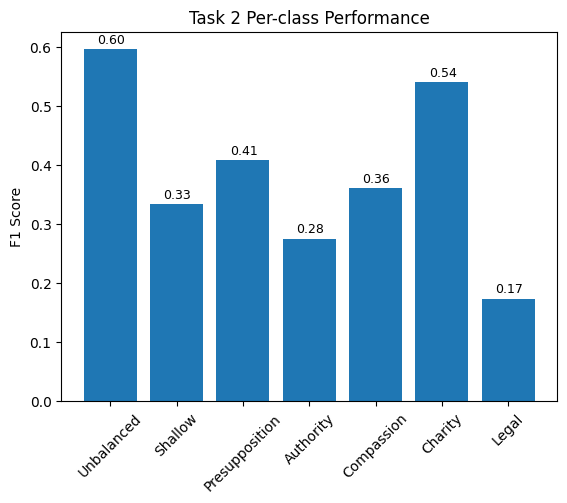

In [36]:
import matplotlib.pyplot as plt

labels_names = ["Unbalanced", "Shallow", "Presupposition", "Authority", "Compassion", "Charity", "Legal"] # 示例名称
plt.bar(range(7), per_class_f1)
plt.xticks(range(7), labels_names, rotation=45)
plt.ylabel('F1 Score')
plt.title('Task 2 Per-class Performance')
for i, v in enumerate(per_class_f1):
    plt.text(i - 0.2, v + 0.01, f"{v:.2f}", fontsize=9)
plt.show()

In [37]:
import os

# Create the BestModel folder
os.makedirs("BestModel", exist_ok=True)

# Save the model weights and configuration files
# This way, GTA will know which checkpoint you are using
trainer.save_model("./BestModel/saved_model")
tokenizer.save_pretrained("./BestModel/saved_model")

print("Best model weights and tokenizer saved to ./BestModel/saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model weights and tokenizer saved to ./BestModel/saved_model
